In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log
import seaborn

samples_file = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/runAll.sh.samples"
meth_ref_file = "/uufs/chpc.utah.edu/common/home/u0914269/clement/projects/20260624_methylseg/data/reference_data/parse450K.pl.order.lookup"

In [3]:
meth_ref = pd.read_csv(meth_ref_file,sep="\t")
meth_ref.shape

(485577, 13)

In [4]:
samples_df = pd.read_csv(samples_file,sep="\t")
samples_df.shape

(9714, 12)

In [8]:
meth_int_high_cutoff = 70
meth_int_low_cutoff = 20

def load_meth(sample_name):
        sample_row = samples_df.loc[samples_df['sample'] == sample_name]
        meth_file = sample_row['methylation_file'].item()

        #print('sample row: ' + str(sample_row))
        #print('meth file: ' + str(meth_file))
        meth = np.load(meth_file).astype(float)
        meth[meth == 255] = np.nan
        
        tmp_meth = meth_ref.copy()
        tmp_meth[sample_name] = meth
        
        return tmp_meth,sample_row

def plot_tcga_sample(sample_name,alpha=0.5,chroms=None,pos=None):
    df, sample_row = load_meth(sample_name)

    df['x_pos'] = 0
    if chroms is not None:
        for idx,chrom in enumerate(chroms):
            df = df[df['CpG_chrm'].isin(chroms)]
            if pos is not None and len(pos) > idx:
                (chr_start,chr_end) = pos[idx]
                df = df[(df['CpG_beg'] >= chr_start) & (df['CpG_beg'] <= chr_end)]
    

    chromosome_order = {'chr1': 1, 'chr2': 2, 'chr3': 3, 'chr4': 4, 'chr5': 5,
                            'chr6': 6, 'chr7': 7, 'chr8': 8, 'chr9': 9, 'chr10': 10,
                            'chr11': 11, 'chr12': 12, 'chr13': 13, 'chr14': 14, 'chr15': 15,
                            'chr16': 16, 'chr17': 17, 'chr18': 18, 'chr19': 19, 'chr20': 20,
                            'chr21': 21, 'chr22': 22, 'chrX': 23, 'chrY': 24}
    chroms = sorted(df['CpG_chrm'].unique(), key=lambda x: chromosome_order[x] if x in chromosome_order else 25)

    last_max_pos = 0
    chrom_labels = []
    chrom_positions = []
    for chrom in chroms:
        if 'chr' not in str(chrom): #check for nan
            continue
        chrom_labels.append(chrom)
        mask_rows = df['CpG_chrm'] == chrom
        first_pos = df[mask_rows]['CpG_beg'].values[0]
        last_pos = df[mask_rows]['CpG_beg'].values[-1]
        vals = df[mask_rows]['CpG_beg'] + last_max_pos
        df.loc[mask_rows,'x_pos'] = df[mask_rows]['CpG_beg'] + last_max_pos
        this_mid = int(first_pos + (first_pos+last_pos)/2)
        chrom_positions.append(this_mid + last_max_pos)
        last_max_pos += last_pos
    print('df size: ' + str(df.shape))


    df = df[df['x_pos'] > 0]
    print('post removing unknown chromosomes: ' + str(df.shape))
    
    int_values = (df[sample_name] >= meth_int_low_cutoff) & (df[sample_name] <= meth_int_high_cutoff)
    int_value_count = np.count_nonzero(int_values)
    int_value_pct = np.nan
    if len(df.index) > 0:
        int_value_pct = int_value_count / len(df.index)
    colors = np.where(int_values, 'red', 'blue')

    # plot scatterplot using matplotlib
    fig = plt.figure(figsize=(12,4))
    gs = fig.add_gridspec(1, 2,  width_ratios=(10, 1),
                      
                      wspace=0.01, hspace=0.05)
    ax = fig.add_subplot(gs[0,0])
    hist_ax = fig.add_subplot(gs[0,1])#,sharey=ax) #if we sharey, we can't adjust the presence of ticks separately
    ax.scatter(df['x_pos'], df[sample_name],s=0.5,c=colors,alpha=alpha)
    
    if len(chrom_labels) == 1:
        ax.set_xlabel(chrom_labels[0])
        ax.ticklabel_format(style='plain')
    else:
        ax.set_xticks(chrom_positions, chrom_labels,rotation=90)
        ax.set_xlabel('Chromosome')


    ax.set_ylabel('Methylation Value')
    ax.set_title('Scatterplot of CpG Methylation - ' + \
              sample_row['sample'].item() + "\n" + \
              sample_row['project_id'].item() + ' ' + sample_row['project_descriptor'].item()  + \
                 ' - ' + sample_row['sample_type'].item())


    
    hist_n, hist_bins, hist_patches = hist_ax.hist(df[sample_name],orientation='horizontal',bins=30)
    for i in range(len(hist_patches)):
        if meth_int_low_cutoff <= hist_patches[i].get_y() < meth_int_high_cutoff:
            hist_patches[i].set_fc('red')
        else:
            hist_patches[i].set_fc('blue')
    
    
    [xmin01, xmax01, ymin01, ymax01] = ax.axis() #set same axis limits
    hist_ax.set_ylim(bottom=ymin01, top=ymax01)
    hist_ax.yaxis.set_tick_params(labelleft=False)
    hist_ax.yaxis.set_ticks([])
    hist_ax.yaxis.set_ticklabels([])
    
    hist_ax.text(0.2,0.5,str(round(100*int_value_pct,2))+"%",transform=hist_ax.transAxes)
    plt.show()

df size: (2721, 15)
post removing unknown chromosomes: (2721, 15)


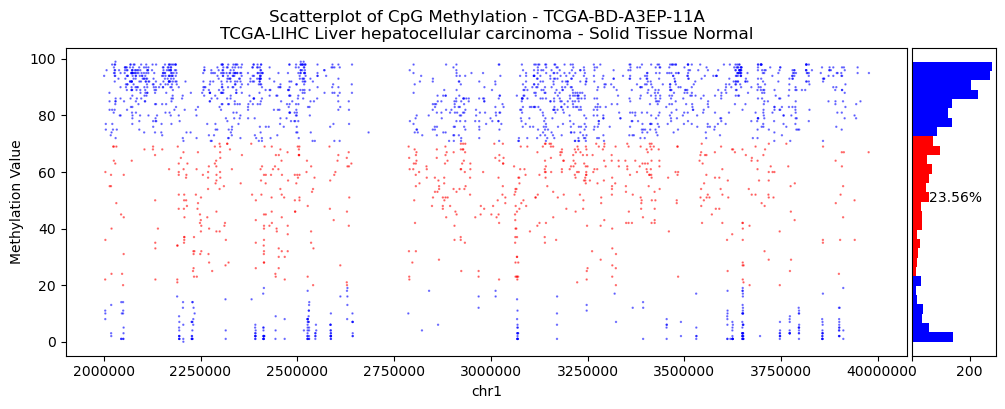

In [11]:
plot_tcga_sample('TCGA-BD-A3EP-11A',chroms=['chr1'],pos=[(2000000,4000000)])

df size: (2721, 15)
post removing unknown chromosomes: (2721, 15)


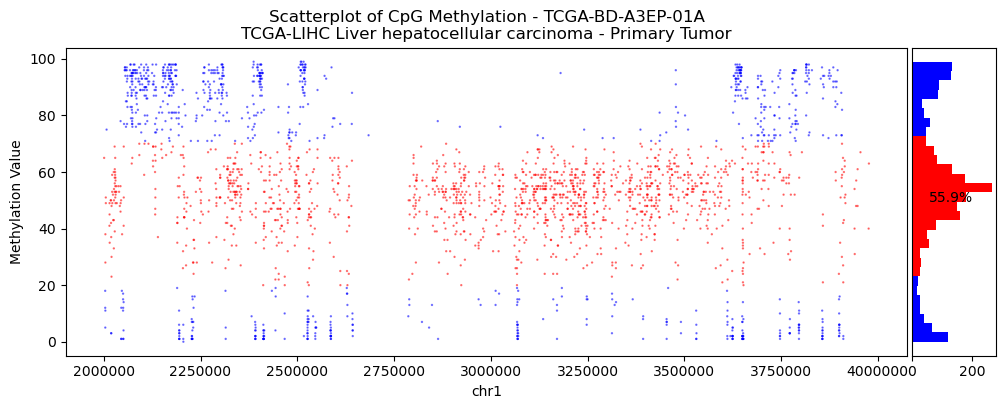

In [12]:
plot_tcga_sample('TCGA-BD-A3EP-01A',chroms=['chr1'],pos=[(2000000,4000000)])